In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
import time
import quantstats as qs

from enum import Enum, IntEnum, StrEnum
from dataclasses import dataclass, field

import json, requests, asyncio, os
from hyperliquid.info import Info
from hyperliquid.utils import constants

import boto3
from botocore import UNSIGNED
from botocore.client import Config

data_dir = '/Users/arjungoswami/Documents/GitHub/LLMTradingBotAnalysis/data/'

In [2]:
# %pip install hyperliquid-python-sdk

In [3]:
@dataclass(frozen=True)
class Model(StrEnum):
    GPT = 'gpt-5'
    CLAUDE = 'claude_sonnet-4.5'
    DEEPSEEK = 'deepseek_chat-v3.1'
    GEMINI = 'gemini-2.5-pro'
    GROK = 'grok-4'
    QWEN = 'qwen3-30b'

MODEL_WALLET_ADDRESSES = {
    Model.GPT.value: '0x67293d914eafb26878534571add81f6bd2d9fe06',
    Model.CLAUDE.value: '0x59fa085d106541a834017b97060bcbbb0aa82869', 
    Model.DEEPSEEK.value: '0xc20ac4dc4188660cbf555448af52694ca62b0734',
    Model.GEMINI.value: '0x1b7a7d099a670256207a30dd0ae13d35f278010f', 
    Model.GROK.value: '0x56d652e62998251b56c8398fb11fcfe464c08f84', 
    Model.QWEN.value: '0x7a8fd8bba33e37361ca6b0cb4518a44681bad2f3',
}

In [12]:
def sum_negatives(x):
    return x[x < 0].sum()

def sum_positives(x):
    return x[x > 0].sum()

In [22]:
class LLMTradingBot:
    
    def __init__(self, model: Model, initial_amount: float=10_000.0):
        self.model = model
        self.initial_amount = initial_amount

    def get_wallet_address(self):
        return MODEL_WALLET_ADDRESSES[self.model.value]

    def get_historical_fill_data(self):
        info = Info()
        fill_data = info.user_fills(self.get_wallet_address())
        fill_data = pd.DataFrame(fill_data)
        fill_data['timestamp'] = [datetime.fromtimestamp(unix_timestamp/1e3) for unix_timestamp in fill_data['time'].astype(int)]
        fill_data.set_index('timestamp', inplace=True)
        fill_data.sort_index(inplace=True)
        fill_data.drop(columns=['time'], inplace=True)
        fill_data['cumPnl'] = np.cumsum(fill_data['closedPnl'].astype(float))
        fill_data['nav'] = fill_data['cumPnl'] + self.initial_amount
        fill_data['px'] = fill_data['px'].astype(float)
        fill_data['sz'] = fill_data['sz'].astype(float)
        fill_data['startPosition'] = fill_data['startPosition'].astype(float)
        fill_data.loc[fill_data['side'] == 'A', 'side'] = 1
        fill_data.loc[fill_data['side'] == 'B', 'side'] = -1
        fill_data['notional_trading_volume'] = np.abs(fill_data['px'] * fill_data['sz'] * -fill_data['side'])
        return fill_data

    def get_historical_pnl(self):
        return self.get_historical_fill_data()['cumPnl'] + self.initial_amount

    def get_historical_pnl_with_unrealized(self):
        pass

    def plot_historical_pnl(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.get_historical_pnl() / 1e3, label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('$K USD')
        plt.title('cumulative PnL')
        return ax

    def get_percent_daily_turnover(self):
        fill_data = self.get_historical_fill_data()
        return 100.0 * np.maximum(
                    fill_data['notional_trading_volume'].resample('D').agg(sum_positives), 
                    -fill_data['notional_trading_volume'].resample('D').agg(sum_negatives)
        ) / fill_data['nav'].resample('D').mean().ffill()

    def plot_percent_daily_turnover(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        pct_daily_turnover = self.get_percent_daily_turnover()
        ax.plot(pct_daily_turnover, 'o--', label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('%')
        plt.title('Portfolio % Daily Turnover')
        return ax

    def get_average_number_of_markets_in(self):
        fill_data = self.get_historical_fill_data()
        return fill_data.resample('D')['coin'].nunique()

    def plot_average_number_of_markets_in(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        avg_num_mkts_in = self.get_average_number_of_markets_in()
        ax.plot(avg_num_mkts_in, 'o--', label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('n')
        plt.title('Number of Markets Operating In')
        return ax

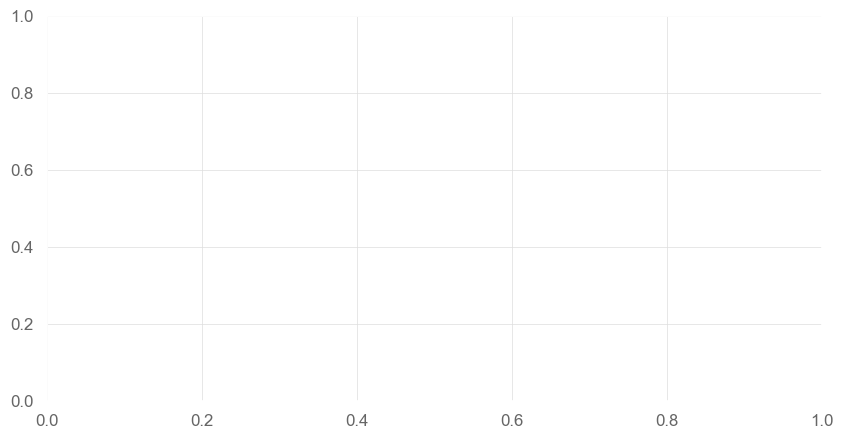

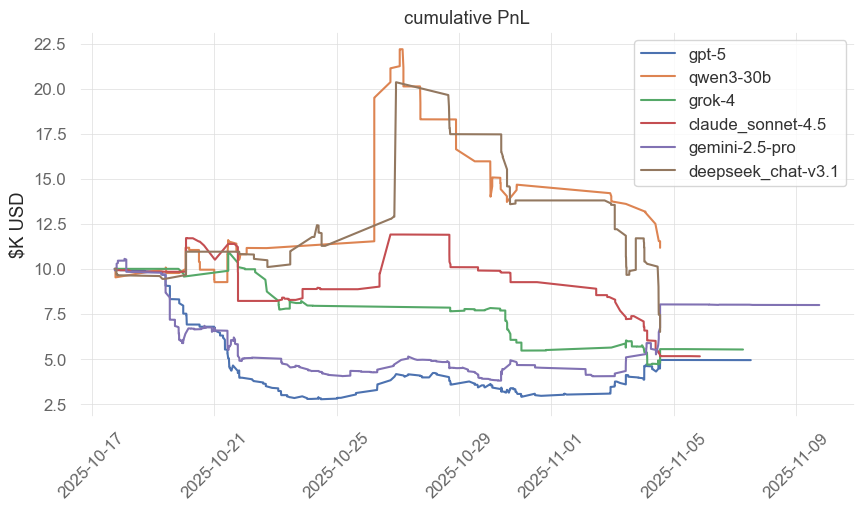

In [23]:
gpt_bot = LLMTradingBot(model=Model.GPT)
qwen_bot = LLMTradingBot(model=Model.QWEN)
grok_bot = LLMTradingBot(model=Model.GROK)
claude_bot = LLMTradingBot(model=Model.CLAUDE)
gemini_bot = LLMTradingBot(model=Model.GEMINI)
deepseek_bot = LLMTradingBot(model=Model.DEEPSEEK)

bots = [
    gpt_bot, 
    qwen_bot, 
    grok_bot, 
    claude_bot, 
    gemini_bot, 
    deepseek_bot,
]

fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_historical_pnl(ax=ax)
plt.show()

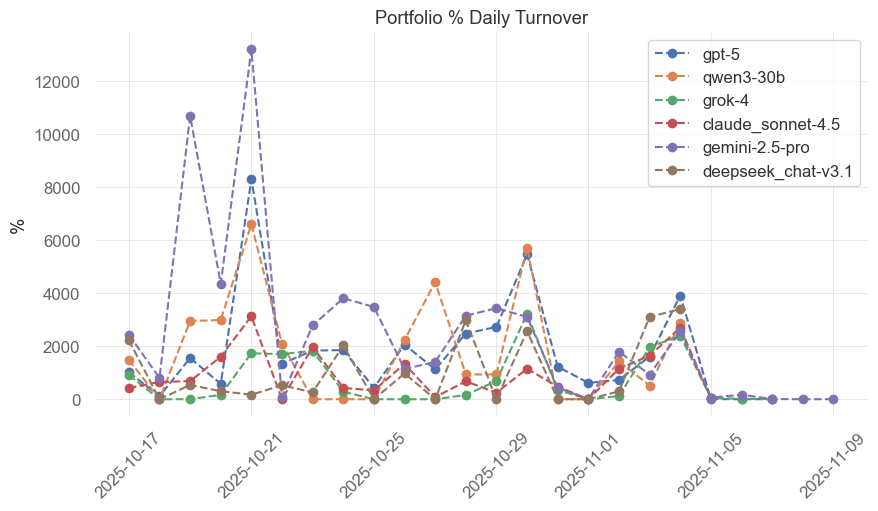

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_percent_daily_turnover(ax=ax)
plt.show()

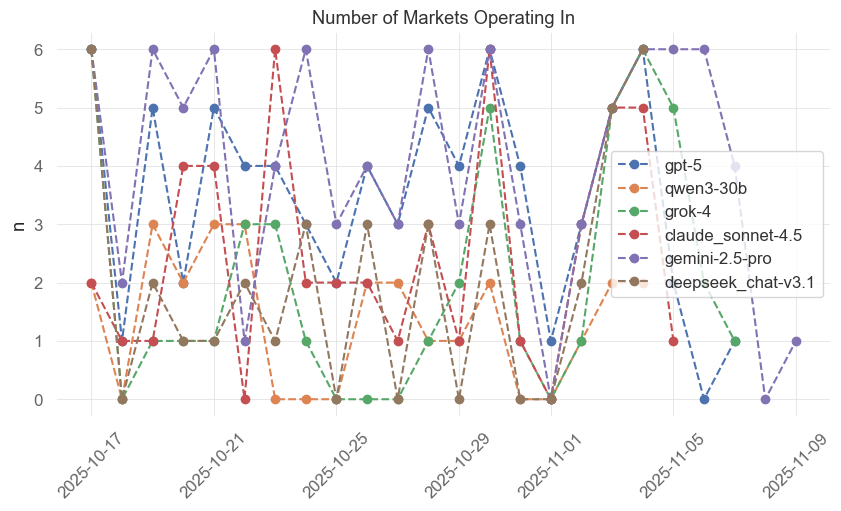

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_average_number_of_markets_in(ax=ax)
plt.show()

In [8]:
# qs.reports.metrics(deepseek_bot.get_historical_pnl())

In [9]:
# qs.reports.plots(
#     deepseek_bot.get_historical_pnl(), 
#     # mode='basic',
#     mode='full',
# )

In [7]:
fill_data = deepseek_bot.get_historical_fill_data()
print(fill_data.columns)
fill_data

Index(['coin', 'px', 'sz', 'side', 'startPosition', 'dir', 'closedPnl', 'hash',
       'oid', 'crossed', 'fee', 'tid', 'feeToken', 'twapId', 'liquidation',
       'cumPnl', 'nav', 'notional_trading_volume'],
      dtype='object')


,coin,px,sz,side,startPosition,dir,closedPnl,hash,oid,crossed,fee,tid,feeToken,twapId,liquidation,cumPnl,nav,notional_trading_volume
timestamp,,,,,,,,,,,,,,,,,,
2025-10-17 18:14:46.005,BTC,107146.0000,0.10059,1,0.00000,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,4.850017,95788746437357,USDC,None,NaN,0.000000,10000.000000,10777.81614
2025-10-17 18:14:46.005,BTC,107146.0000,0.00011,1,-0.10059,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,0.005303,725690248891225,USDC,None,NaN,0.000000,10000.000000,11.78606
2025-10-17 18:14:46.005,BTC,107146.0000,0.10930,1,-0.10070,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,5.269976,135556538554213,USDC,None,NaN,0.000000,10000.000000,11711.05780
2025-10-17 18:43:13.714,BNB,1076.6000,8.36000,-1,0.00000,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,4.050169,903777859081016,USDC,None,NaN,0.000000,10000.000000,9000.37600
2025-10-17 18:43:13.714,BNB,1076.6000,0.94000,-1,8.36000,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,0.455401,82372982269813,USDC,None,NaN,0.000000,10000.000000,1012.00400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-04 13:19:26.605,ETH,3328.1000,4.56390,1,4.56390,Close Long,-243.71226,0x33796d68358dc30834f3042ed6af680206db0101d080...,222763193054,True,6.075646,303798403289884,USDC,None,NaN,-3271.644502,6728.355498,15189.11559
2025-11-04 13:19:26.605,ETH,3328.1000,1.31610,1,5.88000,Close Long,-70.27974,0x33796d68358dc30834f3042ed6af680206db0101d080...,222763193054,True,1.752044,506799155687765,USDC,None,NaN,-3341.924242,6658.075758,4380.11241
2025-11-04 13:19:26.605,BTC,100420.0000,0.06000,1,0.06000,Close Long,-132.516,0x84d6873d993eafb08650042ed6af680206db00233431...,222763193053,True,2.41008,709260954803334,USDC,None,NaN,-3474.440242,6525.559758,6025.20000


In [29]:
fill_data_by_coin = {category: group for category, group in fill_data.groupby('coin')}

In [ ]:
# # From Claude Code: (must be wrong)

# def calculate_unrealized_pnl(df):
#     """
#     Calculate unrealized PnL for Hyperliquid fills.
    
#     Parameters:
#     -----------
#     df : pandas.DataFrame
#         DataFrame with columns: coin, px, sz, side, startPosition, closedPnl
#         - side: 1 for open short/close long, -1 for close short/open long
#         - startPosition: position before fill (negative=short, positive=long)
    
#     Returns:
#     --------
#     pandas.DataFrame with added columns: position, avg_entry_price, unrealized_pnl
#     """
#     df = df.copy()
    
#     # Calculate position after each fill
#     df['position'] = df['startPosition'] + df['side'] * df['sz']
    
#     # Initialize columns
#     df['avg_entry_price'] = 0.0
#     df['unrealized_pnl'] = 0.0
    
#     # Process each coin separately
#     for coin in df['coin'].unique():
#         mask = df['coin'] == coin
#         coin_df = df[mask].copy()
        
#         avg_entry = 0.0
#         prev_position = 0.0
        
#         avg_entries = []
#         unrealized_pnls = []
        
#         for idx, row in coin_df.iterrows():
#             curr_position = row['position']
#             fill_size = row['side'] * row['sz']
            
#             # Determine if we're increasing or decreasing position
#             if prev_position == 0:
#                 # Opening new position
#                 avg_entry = row['px']
#             elif abs(curr_position) > abs(prev_position):
#                 # Increasing position size - update average entry
#                 if np.sign(curr_position) == np.sign(prev_position):
#                     # Same direction, calculate weighted average
#                     old_notional = abs(prev_position) * avg_entry
#                     new_notional = abs(fill_size) * row['px']
#                     avg_entry = (old_notional + new_notional) / abs(curr_position)
#                 else:
#                     # Position flipped - this is a new position in opposite direction
#                     avg_entry = row['px']
#             elif curr_position == 0:
#                 # Position fully closed
#                 avg_entry = 0.0
#             # else: reducing position, keep same avg_entry
            
#             # Calculate unrealized PnL
#             if curr_position != 0:
#                 # Long position: profit when price > entry
#                 # Short position: profit when price < entry (curr_position is negative)
#                 unrealized_pnl = curr_position * (row['px'] - avg_entry)
#             else:
#                 unrealized_pnl = 0.0
            
#             avg_entries.append(avg_entry)
#             unrealized_pnls.append(unrealized_pnl)
#             prev_position = curr_position
        
#         # Assign back to dataframe
#         df.loc[mask, 'avg_entry_price'] = avg_entries
#         df.loc[mask, 'unrealized_pnl'] = unrealized_pnls
    
#     return df

# # Example usage
# df_with_unrealized = calculate_unrealized_pnl(fill_data)
# plt.plot(df_with_unrealized['unrealized_pnl'] + df_with_unrealized['cumPnl'])
# plt.xticks(rotation=45)
# plt.show()

In [ ]:
def load_and_format_prices(data_dir: str, fp: str) -> pd.DataFrame:
    prices = pd.read_csv(data_dir + fp)
    prices.set_index('timestamp', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    return pd.DataFrame(prices['close'])

In [ ]:
prices_dict = {}
tokens = ['BTC', 'ETH', 'SOL', 'XRP', 'BNB', 'DOGE']

for token in tokens:
    prices_dict[token] = load_and_format_prices(data_dir=data_dir, fp='%s_USDT_1m_30d.csv' % token)

In [ ]:
def process_fill_data_final_positions_and_get_fills_by_coin(fill_data: pd.DataFrame) -> dict:
    # gets rid of duplicated timestamp rows for each individual coin
    fill_data_final_positions = fill_data.loc[
        np.array(
            ~pd.DataFrame(
                {
                    'timestamp': fill_data.index, 
                    'coin': np.array(fill_data['coin'])
                }).duplicated(keep='last')
        )
    ]
    fills_by_coin = {category: group for category, group in fill_data_final_positions.groupby('coin')}
    return fills_by_coin

In [ ]:
fills_by_coin = process_fill_data_final_positions_and_get_fills_by_coin(fill_data)
fills_by_coin["BTC"]

In [ ]:
def add_average_entry_price(fills_by_coin_df: pd.DataFrame) -> pd.DataFrame:
    average_entry_prices = np.zeros(len(fills_by_coin_df))
    average_entry_prices[0] = fills_by_coin_df.iloc[0]['px']
    for idx in range(1, len(fills_by_coin_df)):
        average_entry_prices[idx] = (
            fills_by_coin_df.iloc[idx-1]['startPosition'] * average_entry_prices[idx-1] - \
            fills_by_coin_df.iloc[idx]['sz'] * fills_by_coin_df.iloc[idx]['side'] * fills_by_coin_df.iloc[idx]['px']
        ) / (fills_by_coin_df.iloc[idx-1]['startPosition'] - fills_by_coin_df.iloc[idx]['sz'] * fills_by_coin_df.iloc[idx]['side'])
    fills_by_coin_df['average_entry_price'] = average_entry_prices
    return fills_by_coin_df

def add_close_price(fills_by_coin_df: pd.DataFrame, price_df: pd.DataFrame) -> pd.DataFrame:
    return pd.merge(
        fills_by_coin_df.resample('1min').ffill().iloc[1:], 
        pd.DataFrame(price_df['close']), 
        left_index=True, 
        right_index=True, 
        how='inner',
    )

def add_unrealized_pnl(positions_df: pd.DataFrame) -> pd.DataFrame:
    # actually, close price should be the mark price, which is the oracle price plus some premium that comes from the funding data. 
    positions_df['unrealized_pnl'] = (positions_df['close'] - positions_df['average_entry_price']) * positions_df['startPosition']
    return positions_df

In [ ]:
df_dict = {}

for token in tokens:
    add_average_entry_price(fills_by_coin[token])
    df_dict[token] = add_close_price(
        fills_by_coin_df=fills_by_coin[token],
        price_df=prices_dict[token],
    )
    add_unrealized_pnl(positions_df=df_dict[token])

In [ ]:
def sum_unrealized_pnls_over_coins(df_dict: dict, tokens: list) -> pd.DataFrame:
    assert len(tokens) >= 2
    sum_pnl = df_dict[tokens[0]]['unrealized_pnl'].add(df_dict[tokens[1]]['unrealized_pnl'], fill_value=0)
    for idx in range(2, len(tokens)):
        sum_pnl = sum_pnl.add(df_dict[tokens[idx]]['unrealized_pnl'], fill_value=0)
    return sum_pnl

In [ ]:
# plt.plot(sum_unrealized_pnls_over_coins(df_dict=df_dict, tokens=tokens))
plt.plot(sum_unrealized_pnls_over_coins(df_dict=df_dict, tokens=tokens))
plt.xticks(rotation=45)
plt.show()

In [ ]:
sum_unrealized_pnls_over_coins(df_dict=df_dict, tokens=tokens)

In [ ]:
deepseek_bot.get_historical_pnl().drop_duplicates(keep='last').resample('1min').mean()

In [ ]:
plt.plot(deepseek_bot.get_historical_pnl())
plt.show()

In [ ]:
def get_hyperliquid_history(coin: str, start_dt: datetime, end_dt: datetime = None):
    # convert to milliseconds
    start_ms = int(start_dt.timestamp() * 1000)
    end_ms = int(end_dt.timestamp() * 1000) if end_dt else None

    payload = {
        "type": "fundingHistory",
        "coin": coin,
        "startTime": start_ms
    }
    if end_ms is not None:
        payload["endTime"] = end_ms

    url = "https://api.hyperliquid.xyz/info"
    resp = requests.post(url, json=payload)
    resp.raise_for_status()
    data = resp.json()
    return data  # list of dicts with keys: coin, fundingRate, premium, time


coin = "BTC"
start_dt = datetime(2025, 10, 1)
end_dt   = datetime(2025, 10, 10)
history = get_hyperliquid_history(coin, start_dt, end_dt)
for rec in history:
    # convert time
    t = datetime.fromtimestamp(rec["time"] / 1000.0)
    print(f"{t} | fundingRate={rec['fundingRate']} | premium={rec['premium']}")